# 데이터 로드

In [40]:
# ============================================
# 0. Google Drive Mount
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# 1. Imports
# ============================================
import os
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# ============================================
# 2. Seed Fix
# ============================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ============================================
# 3. Paths
# ============================================
CSV_PATH = "/content/drive/MyDrive/kaggle_study/train.csv"
ZIP_PATH = "/content/drive/MyDrive/kaggle_study/train_images.zip"
IMG_PATH = "/content"

# ============================================
# 4. Unzip Images
# ============================================
# train.csv의 image_id가 /content 아래에 바로 풀린다고 가정
if not os.path.exists("/content/1000015157.jpg"):
    print("압축 푸는 중...")
    !unzip -q "/content/drive/MyDrive/kaggle_study/train_images.zip" -d "/content/"
else:
    print("이미 압축 풀려 있음")

# ============================================
# 5. Load CSV
# ============================================
df = pd.read_csv(CSV_PATH)

print("데이터 개수:", len(df))
print(df.head())
print("\n클래스 분포:")
print(df['label'].value_counts().sort_index())

이미 압축 풀려 있음
데이터 개수: 21397
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

클래스 분포:
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64


In [42]:
# ============================================
# 6. Label Meaning
# ============================================
label_map = {
    0: "Cassava Bacterial Blight",
    1: "Brown Streak Disease",
    2: "Green Mottle",
    3: "Mosaic Disease",
    4: "Healthy"
}

# EDA

| label | 의미                        |
| ----- | ------------------------- |
| 0     | Cassava Bacterial Blight  |
| 1     | Brown Streak Disease      |
| 2     | Green Mottle              |
| 3     | Mosaic Disease  |
| 4     | Healthy                   |


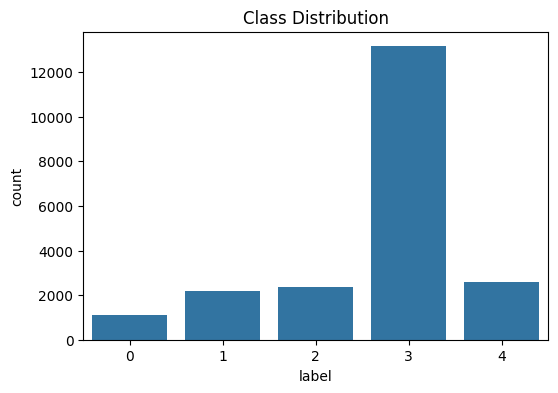

label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64


In [43]:
# ============================================
# 7. EDA - Class Distribution
# ============================================
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

print(df['label'].value_counts())

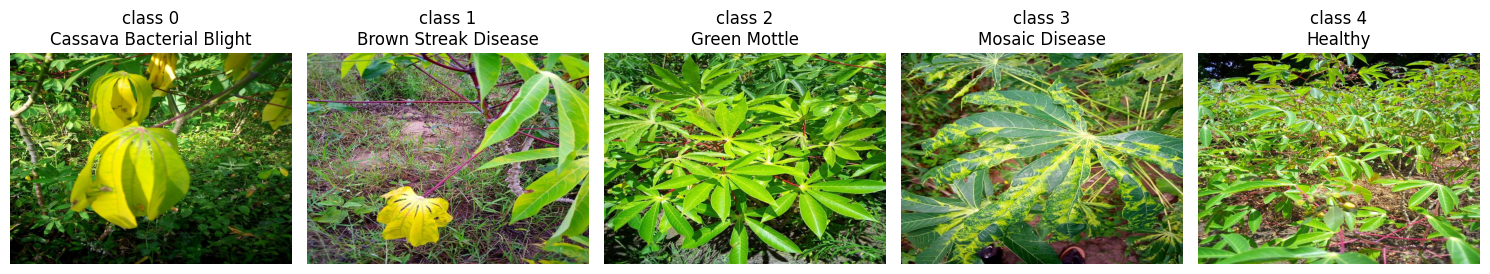

In [44]:
# ============================================
# 8. Sample Images
# ============================================
plt.figure(figsize=(15, 4))

for label in range(5):
    sample = df[df['label'] == label].sample(1, random_state=42)
    img_path = os.path.join(IMG_PATH, sample.iloc[0]['image_id'])
    img = Image.open(img_path).convert("RGB")

    plt.subplot(1, 5, label + 1)
    plt.imshow(img)
    plt.title(f"class {label}\n{label_map[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

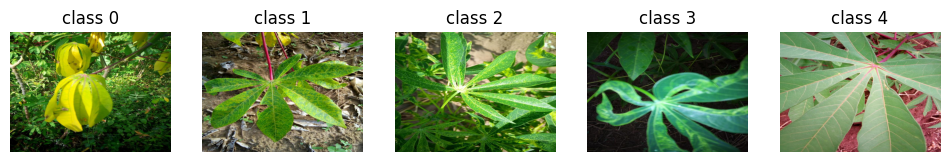

In [45]:
plt.figure(figsize=(12,5))

for label in range(5):
    sample = df[df['label'] == label].sample(1)
    img_path = os.path.join(IMG_PATH, sample.iloc[0]['image_id'])

    img = Image.open(img_path)

    plt.subplot(1,5,label+1)
    plt.imshow(img)
    plt.title(f"class {label}")
    plt.axis('off')

plt.show()

In [46]:
sizes = []

for i in range(300):
    img_path = os.path.join(IMG_PATH, df.iloc[i]['image_id'])
    img = Image.open(img_path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("width 평균:", sum(widths)/len(widths))
print("height 평균:", sum(heights)/len(heights))

width 평균: 800.0
height 평균: 600.0


# baseline

In [47]:
# ============================================
# 9. Train / Validation Split
# ============================================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())

print("\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())

Train size: 17117
Val size: 4280

Train label distribution:
label
0      870
1     1751
2     1909
3    10526
4     2061
Name: count, dtype: int64

Val label distribution:
label
0     217
1     438
2     477
3    2632
4     516
Name: count, dtype: int64


In [48]:
# ============================================
# 10. Transforms
# ============================================
# 이미지에 배경, 흙, 신발 등이 섞여 있으므로
# 단순 Resize보다 RandomResizedCrop이 더 유리할 수 있음.
# pretrained ResNet 사용 시 ImageNet normalization 필수에 가까움.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3),
        value='random'
    )
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [49]:
# ============================================
# 11. Dataset
# ============================================
class CassavaDataset(Dataset):
    def __init__(self, df, img_path, transform=None):
        self.df = df
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_id']
        label = int(self.df.iloc[idx]['label'])

        img_path = os.path.join(self.img_path, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

train_dataset = CassavaDataset(train_df, IMG_PATH, transform=train_transform)
val_dataset = CassavaDataset(val_df, IMG_PATH, transform=val_transform)

In [50]:
# ============================================
# 12. Imbalance Handling - WeightedRandomSampler
# ============================================
# class 3가 훨씬 많으므로, train loader에서 클래스 균형이 좀 맞게 샘플링
class_counts = train_df['label'].value_counts().sort_index().values
print("Train class counts:", class_counts)

class_weights = 1.0 / class_counts
sample_weights = train_df['label'].map(lambda x: class_weights[x]).values
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Train class counts: [  870  1751  1909 10526  2061]


In [51]:
# ============================================
# 13. DataLoader
# ============================================
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,   # shuffle 대신 sampler 사용
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))


train batches: 535
val batches: 134


In [52]:
# ============================================
# 14. Device
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ============================================
# 15. Model - ResNet50
# ============================================
# Dropout을 약간 넣어서 overfitting 완화
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 5)
)
model = model.to(device)


device: cuda


In [53]:
# ============================================
# 16. Loss / Optimizer / Scheduler
# ============================================
# sampler를 이미 쓰고 있으므로 loss에 class weight를 또 세게 주진 않음
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

scaler = GradScaler()

# ============================================
# 17. Metrics
# ============================================
def calculate_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast():
                outputs = model(images)

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

/tmp/ipykernel_1237/4014276870.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [54]:
# ============================================
# 18. Train / Validate Functions
# ============================================
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        acc = calculate_accuracy(outputs, labels)

        running_loss += loss.item()
        running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            acc = calculate_accuracy(outputs, labels)

            running_loss += loss.item()
            running_acc += acc

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, macro_f1

In [55]:
# ============================================
# 19. Early Stopping
# ============================================
class EarlyStopping:
    def __init__(self, patience=5, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True

        improved = (score > self.best_score) if self.mode == 'max' else (score < self.best_score)

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

early_stopper = EarlyStopping(patience=5, mode='max')

In [56]:
# ============================================
# 20. Training Loop
# ============================================
NUM_EPOCHS = 10
best_val_f1 = 0.0

train_losses, train_accs = [], []
val_losses, val_accs, val_f1s = [], [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device
    )

    val_loss, val_acc, val_f1 = validate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")
    print(f"LR: {current_lr:.6f}")
    print("-" * 60)

    # best model 저장 기준: macro F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "/content/best_resnet50_cassava.pth")
        print("Best model saved based on Macro F1!")

    if early_stopper.step(val_f1) is False and early_stopper.early_stop:
        print("Early stopping triggered.")
        break

print(f"Best Validation Macro F1: {best_val_f1:.4f}")

/tmp/ipykernel_1237/118770343.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1237/118770343.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10]
Train Loss: 1.0215 | Train Acc: 0.6784
Val   Loss: 0.8174 | Val   Acc: 0.7919 | Val Macro F1: 0.6924
LR: 0.000300
------------------------------------------------------------
Best model saved based on Macro F1!


/tmp/ipykernel_1237/118770343.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1237/118770343.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/10]
Train Loss: 0.8504 | Train Acc: 0.7750
Val   Loss: 0.8213 | Val   Acc: 0.7877 | Val Macro F1: 0.6896
LR: 0.000300
------------------------------------------------------------


/tmp/ipykernel_1237/118770343.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1237/118770343.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch [8/10]
Train Loss: 0.5872 | Train Acc: 0.9132
Val   Loss: 0.7882 | Val   Acc: 0.8306 | Val Macro F1: 0.7339
LR: 0.000150
------------------------------------------------------------
Best model saved based on Macro F1!


/tmp/ipykernel_1237/118770343.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1237/118770343.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [9/10]
Train Loss: 0.5668 | Train Acc: 0.9214
Val   Loss: 0.7837 | Val   Acc: 0.8324 | Val Macro F1: 0.7203
LR: 0.000150
------------------------------------------------------------


/tmp/ipykernel_1237/118770343.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1237/118770343.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [10/10]
Train Loss: 0.5449 | Train Acc: 0.9345
Val   Loss: 0.7776 | Val   Acc: 0.8341 | Val Macro F1: 0.7291
LR: 0.000150
------------------------------------------------------------
Best Validation Macro F1: 0.7339


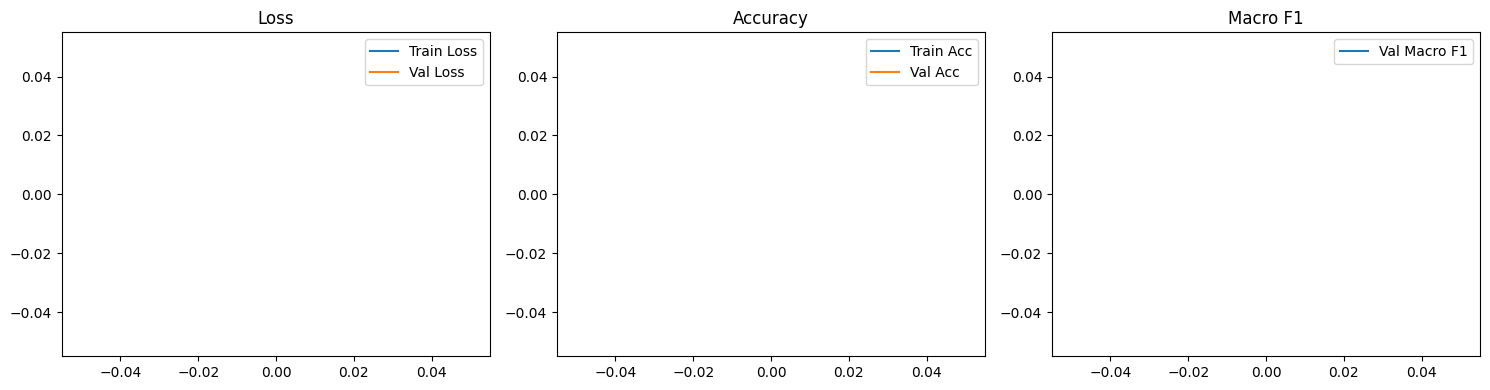

In [57]:
# ============================================
# 21. Load Best Model
# ============================================
model.load_state_dict(torch.load("/content/best_resnet50_cassava.pth"))
model.eval()

# ============================================
# 22. Plot Training Curves
# ============================================
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_f1s, label='Val Macro F1')
plt.title("Macro F1")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1237/4014276870.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:
                          precision    recall  f1-score   support

Cassava Bacterial Blight     0.6089    0.6313    0.6199       217
    Brown Streak Disease     0.7517    0.7397    0.7457       438
            Green Mottle     0.6742    0.7463    0.7085       477
          Mosaic Disease     0.9721    0.8864    0.9273      2632
                 Healthy     0.5819    0.7849    0.6683       516

                accuracy                         0.8306      4280
               macro avg     0.7178    0.7577    0.7339      4280
            weighted avg     0.8509    0.8306    0.8375      4280



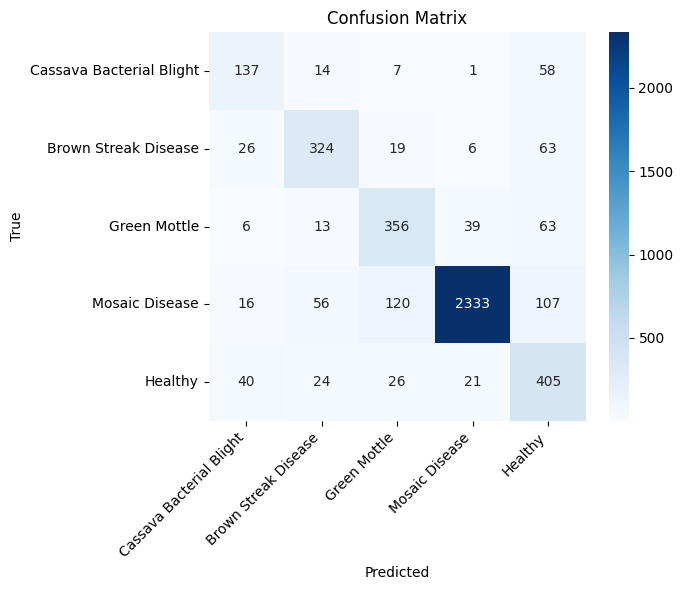

In [58]:
# ============================================
# 23. Final Evaluation
# ============================================
y_pred, y_true = get_predictions_and_labels(model, val_loader, device)

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[label_map[i] for i in range(5)],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[label_map[i] for i in range(5)],
    yticklabels=[label_map[i] for i in range(5)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
# ============================================
# 24. Per-Class Accuracy
# ============================================
per_class_acc = {}

for cls in range(5):
    cls_idx = (y_true == cls)
    cls_total = cls_idx.sum()
    cls_correct = (y_pred[cls_idx] == cls).sum()
    per_class_acc[cls] = cls_correct / cls_total if cls_total > 0 else 0.0

print("Per-class Accuracy:")
for cls, acc in per_class_acc.items():
    print(f"Class {cls} ({label_map[cls]}): {acc:.4f}")

Per-class Accuracy:
Class 0 (Cassava Bacterial Blight): 0.6313
Class 1 (Brown Streak Disease): 0.7397
Class 2 (Green Mottle): 0.7463
Class 3 (Mosaic Disease): 0.8864
Class 4 (Healthy): 0.7849
